# Polystyrene example

In [1]:
import vacuumms as v
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from IPython.display import Image

In [2]:
# Reconstruct the sample from stored data

gfg=v.Configuration("PS.gfg")  
box_dims=[87.57884525964772, 87.57884525964772, 87.57884525964772]
gfg.setBoxDimensions(box_dims)
gfg.cram() 

## Free Volume Index (FVI)

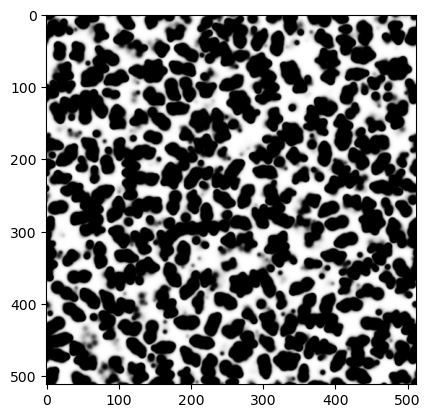

In [4]:
fvi=v.FVIX(gfg)                      # Create the operation object
fvi.setDimensions([1,512,512])        # Set dimensions for result
fvi.execute()                        # Perform the operation
fvi.generateTIFF("PS.tiff")          # Convert the result to a TIFF file
plt.imshow(mpimg.imread('PS.tiff'))  # Prepare and display TIFF image

## Cavity Size Distribution (CESA)

#### Locate and size the cavities

In [4]:
ddx = v.DDX(gfg)              # create the DDX (cavity-search) operation
ddx.setNumberOfSamples(65536) # How many times to search for a cavity
ddx.setNumberOfSteps(50)      # Maximum number of steps before giving up and accepting result without explicit convergence
ddx.setLearningRate(0.01)     # Default is 0.01, sets learning rate for gradient descent of location of center
ddx.setTolerance(10.0)        # 10.0 is default, comparison value to derivative to determine conversion
ddx.setRNGSeed(555)           # Set random number generator seed
ddx.setVerletCutoff(64.0)     # default is 10.0 * 10.0 = 100.0, cutoff radius^2 when building Verlet list
ddx.setVerletExtent(1)        # how many levels of mirror boxes to search when building Verlet list, default is 1
ddx.execute()                 # Run the cavity sizing algorithm

#### Generate the distribution (ASCII dump)

In [5]:
cavs=ddx.getResult()                   # Retrieve the result
cavs.scrubDuplicates()                 # Remove duplicate cavities
csd = v.CavitySizeDistribution(cavs)   # Create the distribution object
csd.setBinWidth(0.05)                  # Set width of bins
csd.setNumberOfBins(81)                # Set number of bins to use
csd.setStartingValue(0.0)              # Set lower limit bin value
csd.generate()                         # Generate the distribution according to parameters specified
csd                                    # Display ASCII rendering of the distribution

0.000000:	
0.050000:	
0.100000:	
0.150000:	
0.200000:	
0.250000:	
0.300000:	*
0.350000:	*
0.400000:	***
0.450000:	*****
0.500000:	******
0.550000:	*********
0.600000:	************
0.650000:	**************
0.700000:	******************
0.750000:	*********************
0.800000:	*************************
0.850000:	*********************************
0.900000:	*****************************************
0.950000:	********************************************************
1.000000:	******************************************************************************
1.050000:	*********************************************************************************************
1.100000:	***************************************************************************************************
1.150000:	**************************************************************************************************
1.200000:	*******************************************************************************************
1.250000:	***********

#### Generate the distribution (pyplot)

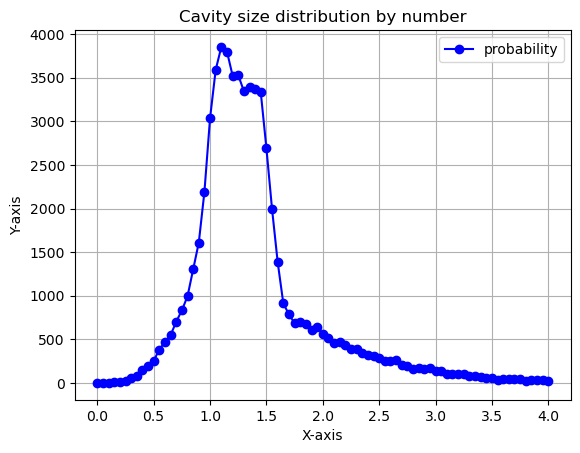

In [10]:
data=csd.getTuples()
x, y = zip(*data)

# Create the plot
plt.plot(x, y, marker='o', linestyle='-', color='b', label='probability')  # Line plot with markers
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Cavity size distribution by number')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

## Visualization

#### Set up the scene object

In [7]:
# Set up the scene object
scene = v.Scene()
scene.setCameraLocation([130,200,300])
scene.setCameraLookAt(tuple(x / 2 for x in box_dims))
scene.applyAmbientLight()
scene.setRenderDimensions(960,540)
scene.clearLightSources()
scene.addLightSource([1000,1000,1000],"White")

#### Create and add components for the atoms and cavities

In [8]:
cc=v.ConfigurationComponent(gfg) # Create the container for the atoms
cc.setTransmit(0.0)              # make it opaque
cc.setPhong(0.9)                 # make it shiny

cavc = v.CavityComponent(cavs)   # Create the container for the cavities
cavc.setPhong(0.6)               # make it shiny
cavc.setTransmit(0.0)            # make it opaque
cavc.setColor("White")           # make it White

scene.addSceneComponent(cc)
scene.addSceneComponent(cavc)

# set view to clip near the edges, so there are no objects dangling on boundary
cc.setBoxDimensions([80,80,80])
cavc.setBoxDimensions([80,80,80])
cc.setClip()            
cavc.setClip()

#### Render the scene

POV-Ray render completed successfully.
POV-Ray temporary file deleted successfully.


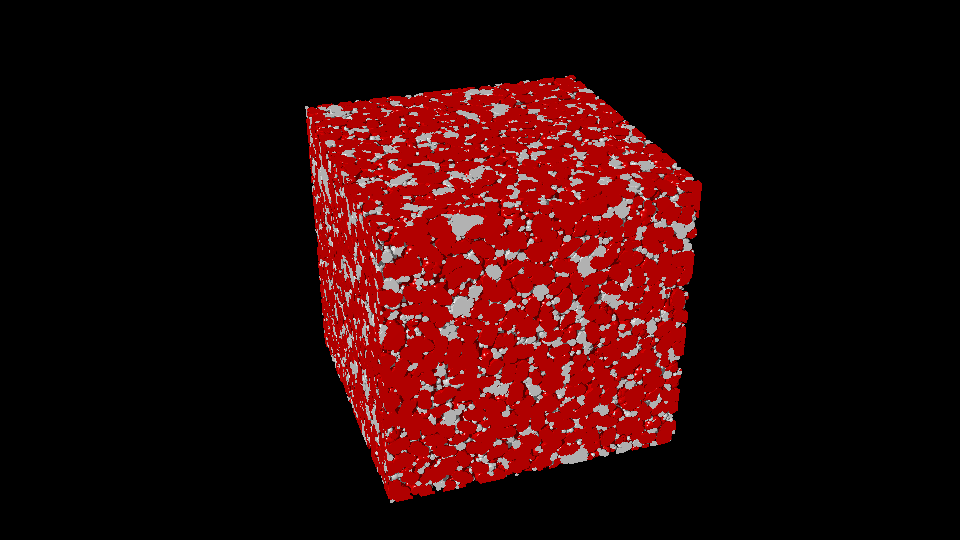

In [9]:
scene.renderScene("PS.png")
Image(filename='PS.png')